# Garbage Classification Evaluation

## 1. Importing Libraries and Defining Constants

In [9]:
# Import Libraries
from pathlib import Path
import sys

from IPython.display import Image
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Add parent directory to path to import src modules
ROOT_DIR = Path().resolve().parent.parent
sys.path.insert(0, str(ROOT_DIR))

from src.models.classifiers import FusionClassifier
from src.data_ingestion.multimodal_ingestion import make_loaders

In [10]:
# Define Paths
SAVE_DIR = ROOT_DIR / "results/"
ACCURACY_CURVE_PATH = SAVE_DIR / "accuracy_curve.png"
LOSS_CURVE_PATH = SAVE_DIR / "loss_curve.png"
PT_PATH = SAVE_DIR / "best.pt"

## 2. Load Generated Content

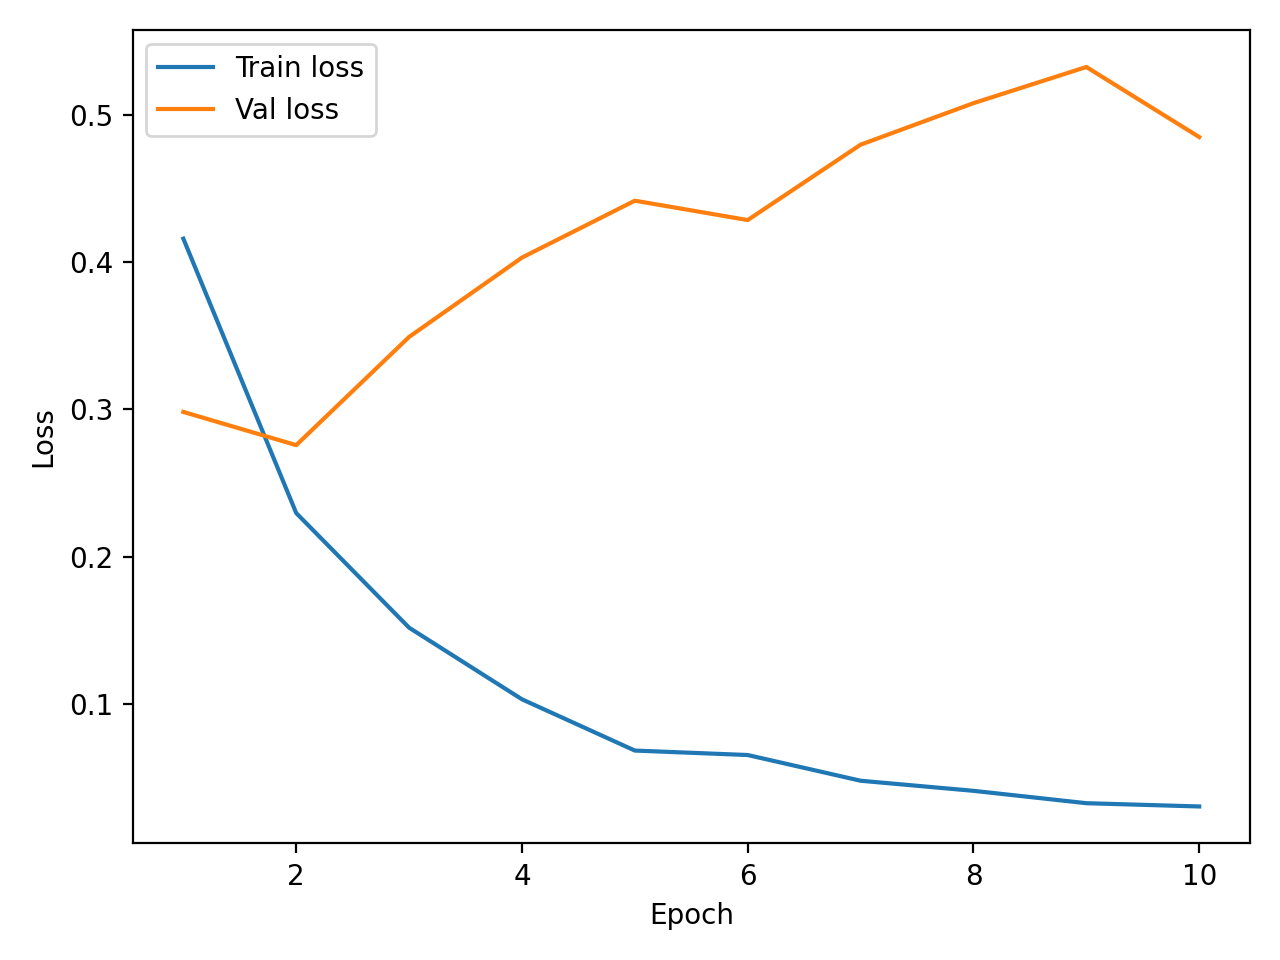

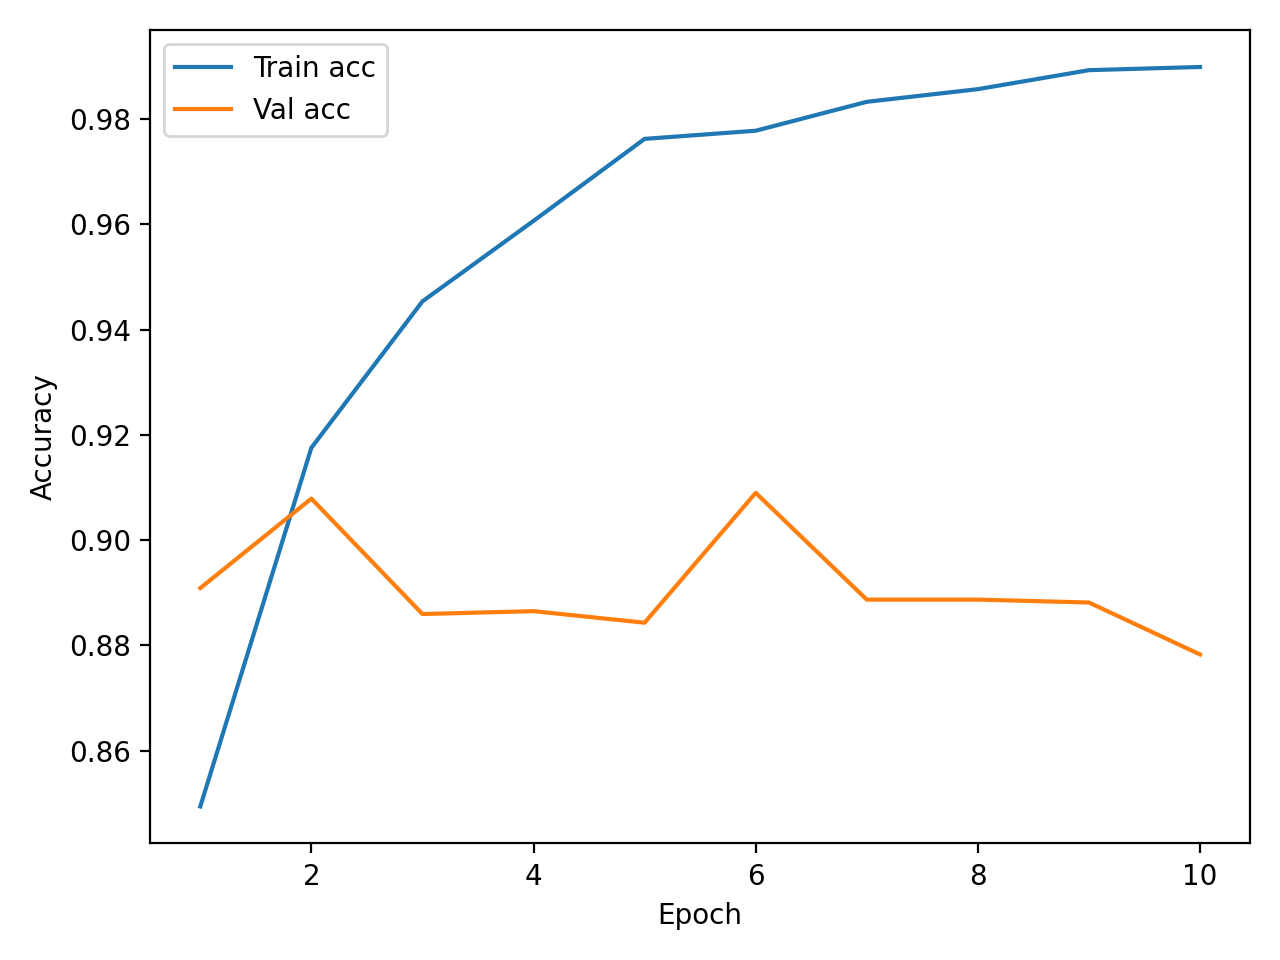

In [11]:
# Display Curve PNGs in the notebook
display(Image(LOSS_CURVE_PATH))
display(Image(ACCURACY_CURVE_PATH))

## 3. Load Model

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [13]:
# Load checkpoint from PT file
checkpoint  = torch.load(PT_PATH, map_location="cpu")
print(checkpoint.keys())

/tmp/ipykernel_2601081/2688077510.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint  = torch.load(PT_PATH, map_location="cpu")


dict_keys(['model_state_dict', 'config', 'class_to_idx'])


In [14]:
# Extract class to index mapping from checkpoint
class_to_index = checkpoint["class_to_idx"]

# Split class to index mapping into variables
class_names = list(class_to_index.keys())
num_classes = len(class_names)

In [15]:
# Extract config dict from checkpoint
config_dict = checkpoint["config"]
print(config_dict)

train_path = config_dict["train_path"]
val_path = config_dict["val_path"]

batch_size = config_dict["batch_size"]
num_workers = config_dict["num_workers"]
epochs = config_dict["epochs"]
lr = config_dict["lr"]
weight_decay = config_dict["weight_decay"]
use_scheduler = config_dict["use_scheduler"]
gamma = config_dict["gamma"]
seed = config_dict["seed"]
text_model_name = config_dict["text_model_name"]
image_encoder_name = config_dict["image_encoder_name"]
text_encoder_name = config_dict["text_encoder_name"]
dropout = config_dict["dropout"]
max_length = config_dict["max_length"]
local_files_only = config_dict["local_files_only"]
freeze_encoders = config_dict["freeze_encoders"]

# Define test path
test_path = "/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Test"

{'train_path': '/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Train', 'val_path': '/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Val', 'batch_size': 32, 'num_workers': 2, 'epochs': 10, 'lr': 0.0001, 'weight_decay': 0.01, 'use_scheduler': False, 'gamma': 0.95, 'save_dir': 'checkpoints', 'seed': 42, 'text_model_name': 'distilbert-base-uncased', 'image_encoder_name': 'convnext_tiny', 'text_encoder_name': 'distilbert', 'dropout': 0.2, 'max_length': 32, 'local_files_only': False, 'freeze_encoders': False}


In [16]:
# Extract model state dict from checkpoint
model_state_dict = checkpoint["model_state_dict"]

In [17]:
# Build model architecture
model = FusionClassifier(
    text_model_name=text_model_name,
    image_encoder_name=image_encoder_name,
    text_encoder_name=text_encoder_name,
    num_classes=num_classes,
    dropout=dropout,
)

# Load model state dict into model architecture
model.load_state_dict(model_state_dict)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 506.31it/s, Materializing param=transformer.layer.5.sa_layer_norm.weight]   
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

In [18]:
# Get test data loader
_, _, test_loader, _ = make_loaders(
    train_path=train_path,
    val_path=val_path,
    test_path=test_path,
    batch_size=batch_size,
    num_workers=num_workers,
    tokenizer_name=text_model_name,
    max_length=max_length,
    local_files_only=local_files_only
)

Class → Index Mapping:
{'Black': 0, 'Blue': 1, 'Green': 2, 'TTR': 3}
Classes:
['Black', 'Blue', 'Green', 'TTR']


## 4. Run Model on Test Set

In [19]:
all_labels  = []
all_preds   = []
all_probs   = []
total_loss  = 0.0
criterion   = nn.CrossEntropyLoss()
n_batches   = 0

with torch.no_grad():
    for batch in test_loader:
        pixel_values  = batch["pixel_values"].to(device)
        input_ids     = batch["input_ids"].to(device)
        attention_mask= batch["attention_mask"].to(device)
        labels        = batch["label"].to(device)

        logits = model(pixel_values, input_ids, attention_mask)
        loss   = criterion(logits, labels)

        probs  = F.softmax(logits, dim=1)
        preds  = torch.argmax(logits, dim=1)

        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())
        total_loss += float(loss.item())
        n_batches  += 1

all_labels = torch.cat(all_labels).numpy()
all_preds  = torch.cat(all_preds).numpy()
all_probs  = torch.cat(all_probs).numpy()

test_loss = total_loss / max(n_batches, 1)
test_acc  = float((all_preds == all_labels).mean())
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Samples      : {len(all_labels)}")

Test Loss    : 0.4752
Test Accuracy: 0.8511  (85.11%)
Samples      : 3432


## 5. Classification Report

In [20]:
report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4
)
print(report)

              precision    recall  f1-score   support

       Black     0.7715    0.7237    0.7468       695
        Blue     0.8006    0.9171    0.8549      1086
       Green     0.9476    0.9287    0.9381       799
         TTR     0.9031    0.7981    0.8474       852

    accuracy                         0.8511      3432
   macro avg     0.8557    0.8419    0.8468      3432
weighted avg     0.8544    0.8511    0.8505      3432



## 6. Confusion Matrix

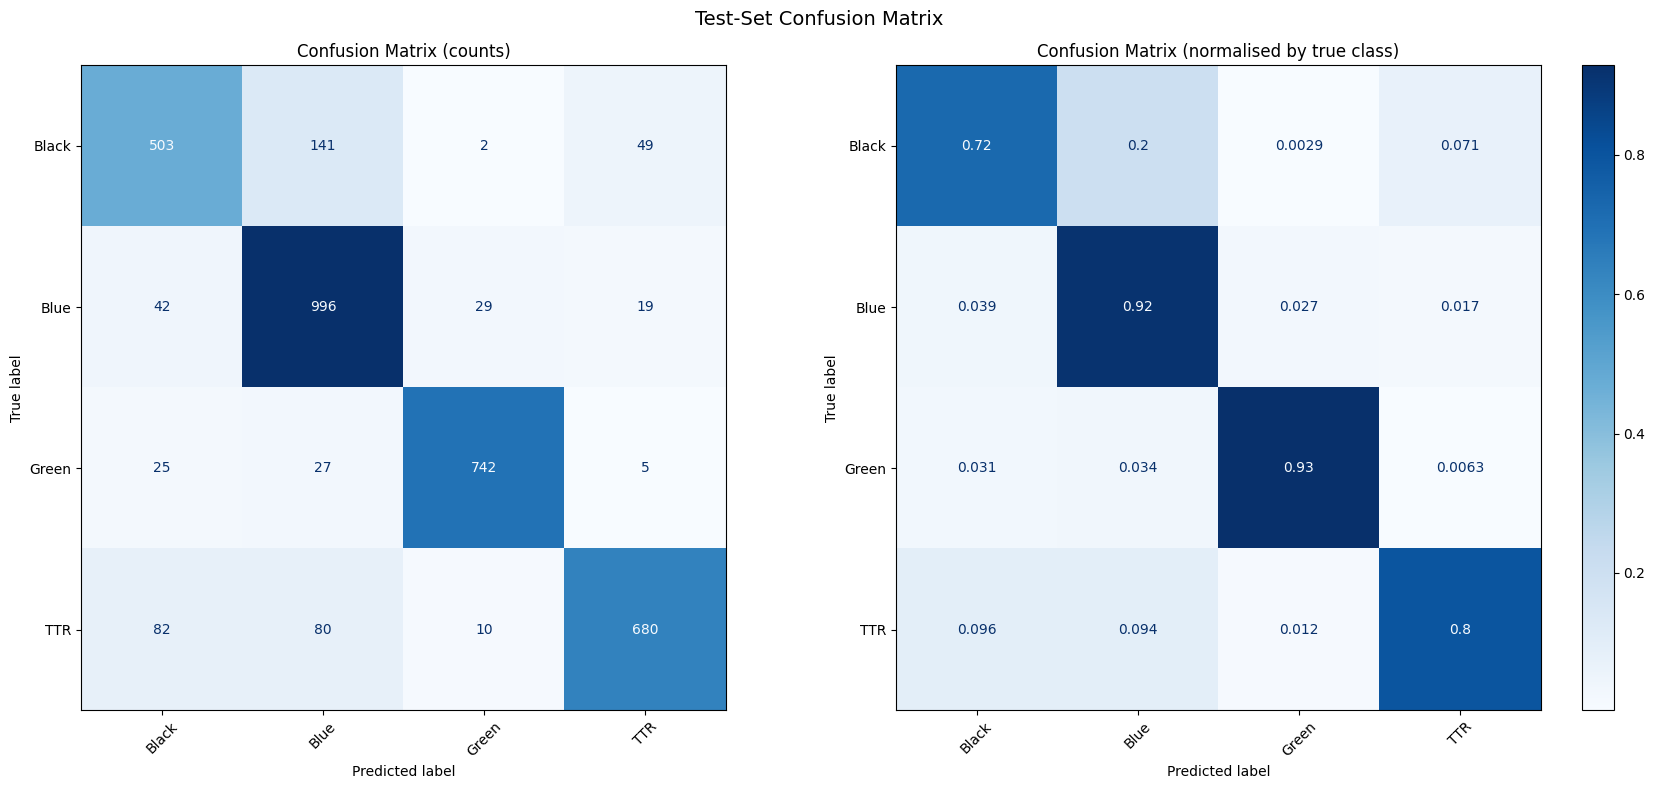

In [21]:
cm = confusion_matrix(all_labels, all_preds)

fig_size = max(8, num_classes)
fig, axes = plt.subplots(1, 2, figsize=(fig_size * 2 + 2, fig_size))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title("Confusion Matrix (counts)")

# Normalised (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=True, xticks_rotation=45)
axes[1].set_title("Confusion Matrix (normalised by true class)")

plt.suptitle("Test-Set Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

## 7. ROC Curves

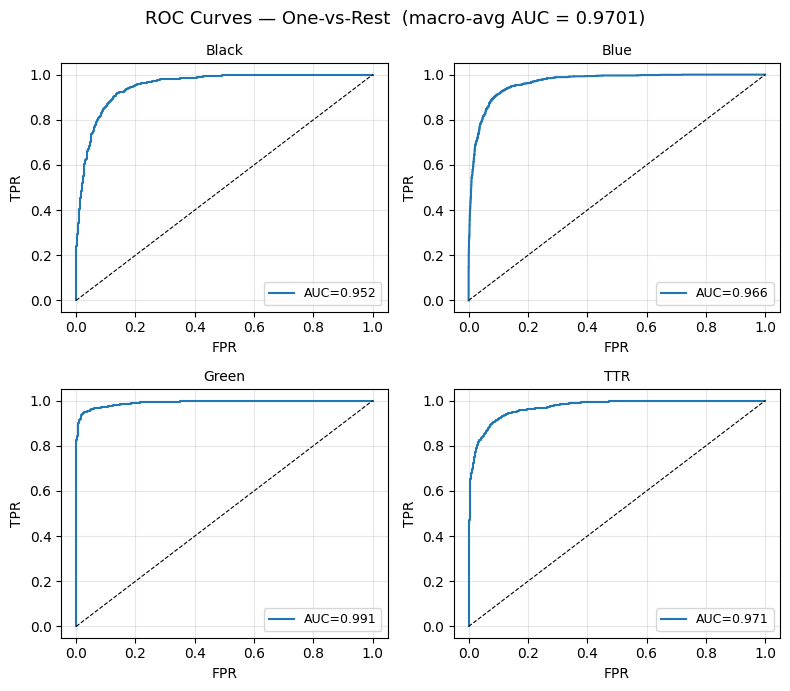

Macro-average AUC: 0.9701


In [22]:
labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))

cols = int(np.floor(np.sqrt(num_classes)))
rows = int(np.ceil(num_classes / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_flat = np.array(axes).flatten()

macro_auc = []
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    macro_auc.append(roc_auc)

    ax = axes_flat[i]
    ax.plot(fpr, tpr, lw=1.5, label=f"AUC={roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(num_classes, len(axes_flat)):
    axes_flat[j].set_visible(False)

macro_mean = float(np.mean(macro_auc))
plt.suptitle(f"ROC Curves — One-vs-Rest  (macro-avg AUC = {macro_mean:.4f})", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Macro-average AUC: {macro_mean:.4f}")

## 8. Per-Class Accuracy

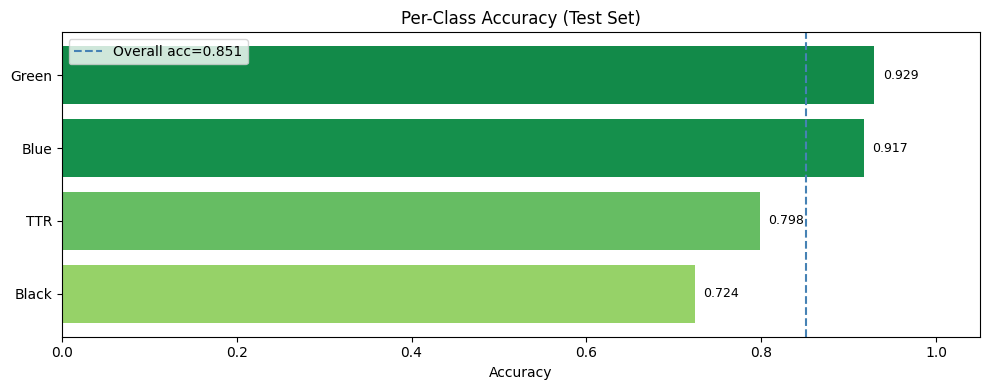

In [23]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
sorted_idx    = np.argsort(per_class_acc)

fig, ax = plt.subplots(figsize=(10, max(4, num_classes * 0.5)))
bars = ax.barh(
    [class_names[i] for i in sorted_idx],
    per_class_acc[sorted_idx],
    color=plt.cm.RdYlGn(per_class_acc[sorted_idx])
)
ax.axvline(test_acc, color="steelblue", linestyle="--", label=f"Overall acc={test_acc:.3f}")
ax.set_xlabel("Accuracy")
ax.set_title("Per-Class Accuracy (Test Set)")
ax.set_xlim(0, 1.05)
ax.legend()
for bar, val in zip(bars, per_class_acc[sorted_idx]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Confidence Distribution

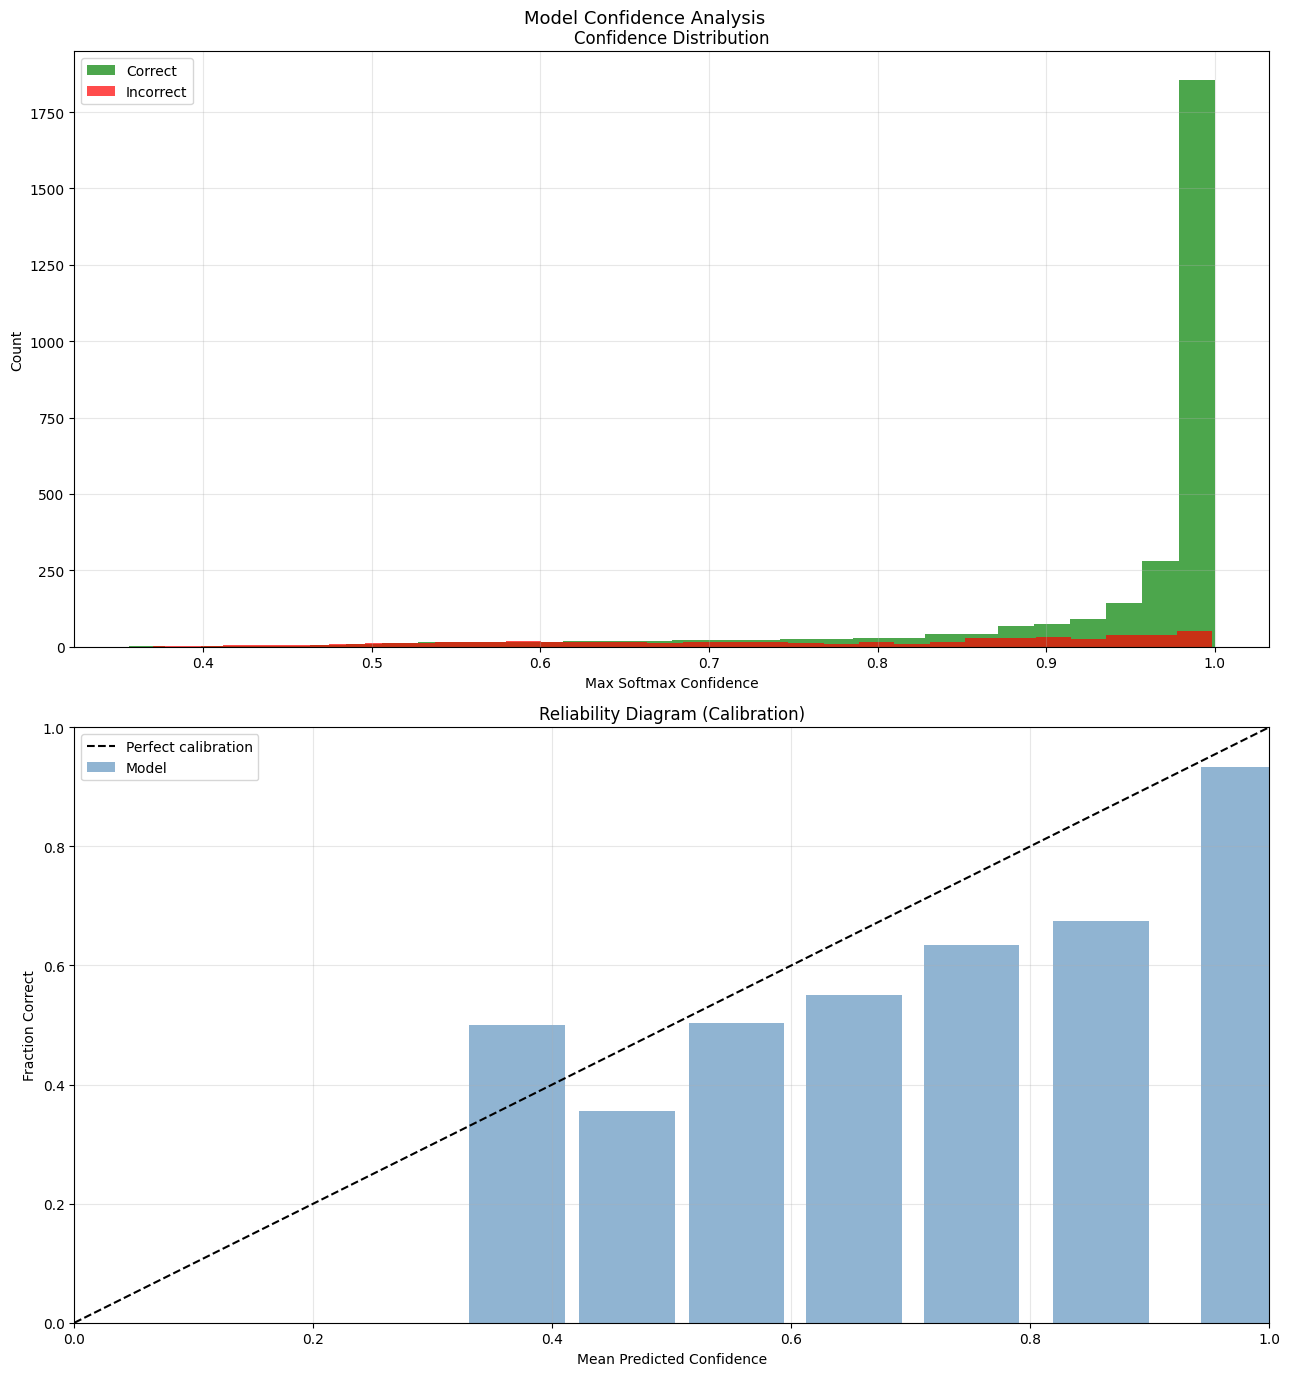

Expected Calibration Error (ECE): 0.0686


In [24]:
max_conf   = all_probs.max(axis=1)   # confidence of predicted class
correct    = (all_preds == all_labels)

fig, axes = plt.subplots(2, 1, figsize=(13, 14))

axes[0].hist(max_conf[correct],  bins=30, alpha=0.7, label="Correct",   color="green")
axes[0].hist(max_conf[~correct], bins=30, alpha=0.7, label="Incorrect", color="red")
axes[0].set_xlabel("Max Softmax Confidence")
axes[0].set_ylabel("Count")
axes[0].set_title("Confidence Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calibration: reliability diagram
n_bins  = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_acc, bin_conf, bin_count = [], [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (max_conf >= lo) & (max_conf < hi)
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(max_conf[mask].mean())
        bin_count.append(mask.sum())

axes[1].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[1].bar(
    bin_conf, bin_acc,
    width=0.08, alpha=0.6, color="steelblue",
    label="Model", align="center"
)
axes[1].set_xlabel("Mean Predicted Confidence")
axes[1].set_ylabel("Fraction Correct")
axes[1].set_title("Reliability Diagram (Calibration)")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Model Confidence Analysis", fontsize=13)
plt.tight_layout()
plt.show()

# ECE
ece = sum(
    bc * abs(ba - bcf)
    for ba, bcf, bc in zip(bin_acc, bin_conf, bin_count)
) / len(all_labels)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

# 10. Most Confused Pairs

In [25]:
# Off-diagonal confusion pairs ranked by count
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if cm_copy[i, j] > 0:
            pairs.append({
                "true": class_names[i],
                "predicted": class_names[j],
                "count": int(cm_copy[i, j])
            })

pairs_df = pd.DataFrame(pairs).sort_values("count", ascending=False).reset_index(drop=True)
print("Top Confused Pairs:")
display(pairs_df)

Top Confused Pairs:


,true,predicted,count
0,Black,Blue,141
1,TTR,Black,82
2,TTR,Blue,80
3,Black,TTR,49
4,Blue,Black,42
5,Blue,Green,29
6,Green,Blue,27
7,Green,Black,25
8,Blue,TTR,19
9,TTR,Green,10


# 11. Summary of Findings

In [26]:
print("="*55)
print("  EVALUATION SUMMARY")
print("="*55)
print(f"  Checkpoint  : {PT_PATH}")
print(f"  Test path   : {test_path}")
print(f"  Samples     : {len(all_labels)}")
print(f"  Classes     : {num_classes}")
print(f"  Device      : {device}")
print("-"*55)
print(f"  Test Loss          : {test_loss:.4f}")
print(f"  Test Accuracy (Top-1): {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Macro-avg AUC      : {macro_mean:.4f}")
print(f"  ECE                : {ece:.4f}")
print("-"*55)
best_class = class_names[int(np.argmax(per_class_acc))]
worst_class = class_names[int(np.argmin(per_class_acc))]
print(f"  Best class  : {best_class}  ({per_class_acc.max():.3f})")
print(f"  Worst class : {worst_class}  ({per_class_acc.min():.3f})")
print("="*55)

  EVALUATION SUMMARY
  Checkpoint  : /home/mahasamilage.senanay/617-Assignment-2/results/best.pt
  Test path   : /work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Test
  Samples     : 3432
  Classes     : 4
  Device      : cpu
-------------------------------------------------------
  Test Loss          : 0.4752
  Test Accuracy (Top-1): 0.8511  (85.11%)
  Macro-avg AUC      : 0.9701
  ECE                : 0.0686
-------------------------------------------------------
  Best class  : Green  (0.929)
  Worst class : Black  (0.724)
